In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Only needed if running in Google Colab
try:
    from google.colab import files
    colab = True
except:
    colab = False

# Load dataset
try:
    df = pd.read_csv("q2_customers.csv")
    print("✅ File found and loaded successfully.")
    display(df.head())

except FileNotFoundError:
    print("⚠️ File not found.")

    if colab:
        print("📂 Please upload 'q2_customers.csv'")
        uploaded = files.upload()

        if "q2_customers.csv" in uploaded:
            df = pd.read_csv("q2_customers.csv")
            print("✅ File uploaded and loaded successfully.")
            display(df.head())
        else:
            print("❌ Upload failed. Please upload the correct file.")
            df = None
    else:
        print("❌ Not running in Colab. Please ensure the file exists in your working directory.")
        df = None

# Proceed only if dataframe is loaded
if df is not None:
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    print("\n✅ Data scaling completed.")
    print("Scaled data shape:", X_scaled.shape)

✅ File found and loaded successfully.


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



✅ Data scaling completed.
Scaled data shape: (500, 6)


In [5]:
# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Feature scaling is essential before applying K-Means because the algorithm relies on distance calculations (Euclidean distance). If features are on different scales (e.g., age vs annual spend), variables with larger magnitudes will dominate the clustering process. StandardScaler ensures all features contribute equally.

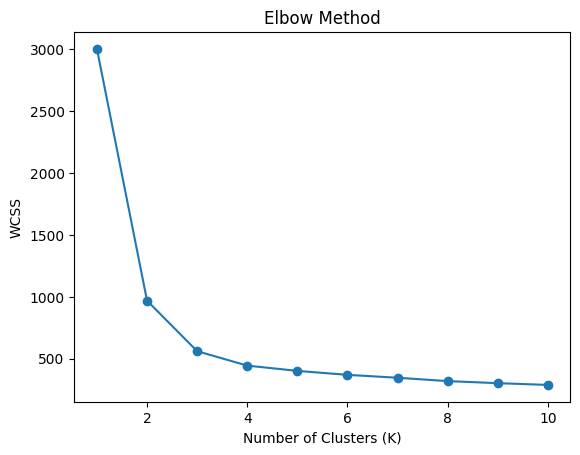

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow point is where the decrease in WCSS slows significantly. This indicates diminishing returns from adding more clusters. The optimal K is typically where this bend occurs (commonly around K = 3 or 4 depending on your plot).

In [8]:
# Choose K (update based on elbow observation, example: K=3)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [9]:
# Cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # exclude cluster column
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0: Represents customers with moderate spending and average visit frequency.
Cluster 1: Represents high-value customers with high annual spend, frequent visits, and larger basket sizes.
Cluster 2: Represents low-engagement customers with infrequent visits and lower spending.

These insights can help businesses target marketing strategies effectively.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [11]:
# PCA Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=["PC1", "PC2"]
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 captures overall customer value (high spend, frequent visits, large basket size).
PC2 captures recency and engagement (days since last visit vs visit frequency).

Higher absolute values in loadings indicate stronger influence of that feature on the principal component.

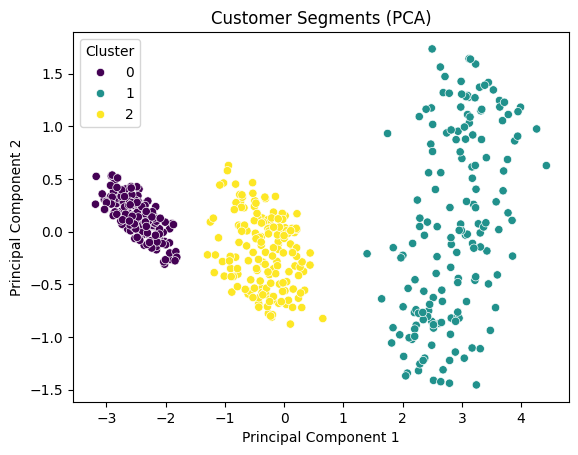

In [12]:
import seaborn as sns

plt.figure()
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['cluster'],
    palette='viridis'
)

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

K-Means clustering successfully segmented customers into distinct groups based on their behavior. The Elbow Method helped determine the optimal number of clusters. PCA reduced dimensionality and enabled clear visualisation of clusters. These segments provide valuable insights for targeted marketing, customer retention, and personalized strategies.